<a href="https://colab.research.google.com/github/juancast-data-analyst/AB-testing-hypothesis-analysis-landing-page/blob/main/S9_Version_Student_Proyecto_Landing_Experiment_F.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Experimento A/B en página de inicio

El objetivo de este proyecto es evaluar un **experimento A/B** realizado en una página de inicio (landing page) con versiónes **A y B** para apoyar una **decisión de negocio basada en datos**.

---

El archivo `landing_experiment.csv` contiene información de usuarios expuestos a dos versiones de la página de inicio (landing page) dentro del experimento A/B. Incluye región, dispositivo, fuente de tráfico, tipo de usuario, conversión y gasto.

El análisis sigue una lógica clara y progresiva:

1. 🔍 Explorar y validar los datos.

2. 💰 Comparar el **gasto promedio** por usuario entre la página A y B.

3. 🎯 Comparar la **tasa de conversión** entre la página A y B.

4. 🌐 Revisar **la relación entre la fuente de tráfico y la conversión**.

5. 👤 Revisar **la relación entre el tipo de usuario y la conversión**.

6. 📈 **Visualizar los resultados**: Respalda tus conclusiones mediante gráficos claros.

Se aplican **puebas estadísticas apropiados** para comparar las páginas y **recomendar qué versión es mejor**, justificando la decisión con datos.

## 🧩 Paso 1: Cargar y validar los datos

### 1.1 Carga de datos y vista rápida

In [ ]:
# importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# cargar archivo
df = pd.read_csv('/datasets/landing_experiment.csv')

**Vista previa e información general del conjunto de datos**

In [ ]:
# mostrar las primeras 5 filas
df.head()

,user_id,date,landing,region,dispositivo,traffic_source,user_type,converted,gasto
0,26f3052e-8500-44ea-8fff-06de65258abb,2026-01-01,A,Norte,Mobile,Email,Recurrente,1,38.08
1,92378c09-4bbf-40c7-945e-82b84f392d22,2026-01-23,A,Occidente,Mobile,Organic,Nuevo,0,0.00
2,a4397360-40e5-45d6-a7ff-dcb4da2c9a1f,2026-01-01,B,Centro,Mobile,Organic,Nuevo,0,0.00
3,7ca3a26f-1e6c-44aa-9b09-b8cb01112956,2026-01-22,A,Centro,Mobile,Ads,Nuevo,0,0.00
4,8dc9593b-5b9c-479d-848b-a99493920419,2026-01-16,A,Sur,Mobile,Organic,Nuevo,0,0.00


In [ ]:
# información general
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_id         40000 non-null  object 
 1   date            40000 non-null  object 
 2   landing         40000 non-null  object 
 3   region          40000 non-null  object 
 4   dispositivo     40000 non-null  object 
 5   traffic_source  40000 non-null  object 
 6   user_type       40000 non-null  object 
 7   converted       40000 non-null  int64  
 8   gasto           40000 non-null  float64
dtypes: float64(1), int64(1), object(7)
memory usage: 2.7+ MB


✍️ **Hallazgos**:

 - No se identifican valores Nulos o Ausentes, existen 40000 entradas y cada variable presenta la misma cantidad de datos
 - El tipo de dato es el adecuado para el desarrollo del Proyecto

**Descripción del conjunto de datos**

El dataset contiene las siguientes columnas:

- `user_id` — Identificador único del usuario
- `date` — Fecha en la que el usuario fue expuesto a la página
- `landing` — Versión de la página mostrada al usuario
- `region` — Región geográfica del usuario
- `dispositivo` — Tipo de dispositivo utilizado por el usuario
- `traffic_source` — Canal por el que llegó el usuario
- `user_type` — Tipo de usuario según historial previo
- `converted` — Indica si el usuario realizó una conversión
- `gasto` — Monto gastado por el usuario (0 si no convirtió)

### 1.2 Análisis exploratorio y revisión de calidad de datos

Se identifican las variables clave del experimento A/B y se valida que estén bien definidas, completas y que sean consistentes.


 **Variable `user_id`**  
 Verificar usuarios únicos

In [ ]:
# Ususarios Únicos
print("Usuarios unicos:", df['user_id'].nunique())

# Ususarios Duplicados
print("Número de Duplicados:", df["user_id"].duplicated().sum())

Usuarios unicos: 40000
Número de Duplicados: 0


 **Variable `date`**  
Explorar rango de fechas

In [ ]:
# Resumen estadístico
df["date"].describe()

count          40000
unique            28
top       2026-01-24
freq            1512
Name: date, dtype: object

In [ ]:
# Identificar rango temporal del experimento
print("Fecha mínima:", df["date"].min())
print("Fecha máxima:", df["date"].max())

Fecha mínima: 2026-01-01
Fecha máxima: 2026-01-28


**Variable `gasto` (numérica)**

In [ ]:
# Resumen estadístico
df['gasto'].describe()

count    40000.000000
mean         9.325554
std         25.667986
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        303.680000
Name: gasto, dtype: float64

In [ ]:
# Resumen estadístico de usuarios que se convirtieron
user_converted = df[df['converted']==1]

user_converted['gasto'].describe()

count    5706.000000
mean       65.373668
std        30.896545
min        12.120000
25%        42.950000
50%        59.860000
75%        80.370000
max       303.680000
Name: gasto, dtype: float64

 **Variables categóricas**  
 Verificar categorías esperadas del experimento ( A y B).

In [ ]:
# Explorar variables categóricas y cómo se distribuyen
print("\nConteo de categorías:")
print()
variables_categoricas = ['landing', 'region', 'dispositivo', 'traffic_source', 'user_type', 'converted']
for col in variables_categoricas:
    print(f"{col}:")
    print(f"Categorías Únicas:")
    print(f"{df[col].unique()}")                                                                     #Valores Únicos
    print()

    # Frecuencias absolutas y porcentajes
    conteos = df[col].value_counts()
    porcentajes = df[col].value_counts(normalize=True) * 100

    print(f"Distribución:")
    for categoria in conteos.index:
        print(f" {categoria}: {conteos[categoria]:,} ({porcentajes[categoria]: .1f}%)")               #Frecuencias Absoluta y Porcentajes
    print("=" * 50)


Conteo de categorías:

landing:
Categorías Únicas:
['A' 'B']

Distribución:
 B: 20,018 ( 50.0%)
 A: 19,982 ( 50.0%)
region:
Categorías Únicas:
['Norte' 'Occidente' 'Centro' 'Sur' 'Oriente']

Distribución:
 Norte: 11,166 ( 27.9%)
 Centro: 9,613 ( 24.0%)
 Sur: 8,039 ( 20.1%)
 Occidente: 6,398 ( 16.0%)
 Oriente: 4,784 ( 12.0%)
dispositivo:
Categorías Únicas:
['Mobile' 'Desktop']

Distribución:
 Mobile: 24,829 ( 62.1%)
 Desktop: 15,171 ( 37.9%)
traffic_source:
Categorías Únicas:
['Email' 'Organic' 'Ads' 'Referral']

Distribución:
 Organic: 17,987 ( 45.0%)
 Ads: 11,935 ( 29.8%)
 Email: 6,123 ( 15.3%)
 Referral: 3,955 ( 9.9%)
user_type:
Categorías Únicas:
['Recurrente' 'Nuevo']

Distribución:
 Nuevo: 26,033 ( 65.1%)
 Recurrente: 13,967 ( 34.9%)
converted:
Categorías Únicas:
[1 0]

Distribución:
 0: 34,294 ( 85.7%)
 1: 5,706 ( 14.3%)


✍️ **Hallazgos**:  

- Todas las variabless tienen valores esperados.
- 40000 usuarios únicos, sin duplicados;
- Rango Temporal del experimento entre el 01-01-2026 y el 28-01-2026;
- Valores positivos > 0 en la variable gasto de acuerdo con resumen estadistico en usuarios que convirtieron;
- Comprobación de la Distribución de las dos versiones de landing aplicadas en el experimento (A/B), 50% de usuarios para cada Version;
- No se identifican categorías mal escritas;

## 💰 Paso 2: Comparar el gasto promedio por usuario (página A vs B)

Se evalua si existen diferencias estadísticamente significativas en el gasto promedio de los **usuarios que se convirtieron en clientes** entre la página A y la página B, para identificar qué versión genera **mayor valor económico** para el negocio.


In [ ]:
# Gasto por versión
gasto_A = df[(df['landing'] == 'A') & (df['converted'] == 1)]['gasto']#completa el código
gasto_B = df[(df['landing'] == 'B') & (df['converted'] == 1)]['gasto']#completa el código

# Verificar cantidad de datos que tiene cada grupo
print(f"Cantidad de usuarios que convirtieron por versión:")
print(f"A:{len(gasto_A)}")
print(f"B:{len(gasto_B)}")

Cantidad de usuarios que convirtieron por versión:
A:2512
B:3194


In [ ]:
#Inspeccionar Información por grupo

for col in ['gasto_A', 'gasto_B']:
    print(f"Versión {col}:")
    print(f"{globals()[col][:5]}")
    print("=" * 50)

Versión gasto_A:
0      38.08
17     42.97
27    119.26
44     74.26
45     61.56
Name: gasto, dtype: float64
Versión gasto_B:
9      27.61
25     70.59
30     57.38
62    109.20
65     97.77
Name: gasto, dtype: float64


### Prueba Estadistica t de Student (t-test).

**Hipótesis:**
- **Hipótesis nula (H₀):** El gasto promedio de los usuarios es igual en la página A y en la página B.
- **Hipótesis alternativa (H₁):** El gasto promedio de los usuarios es diferente en la página A y la página B.

In [ ]:
from scipy.stats import ttest_ind
# Aplicar prueba

t_stat, p_value = ttest_ind(gasto_A, gasto_B)

# Visualizar resultados
print(f"Estadístico t: {t_stat}")
print(f"Valor p: {p_value}")

Estadístico t: -9.36563589591332
Valor p: 1.0635288333792346e-20


In [ ]:
#Umbral de Significancia
alpha = 0.05

#Decision
if p_value < alpha:
    print("Rechazamos la hipótesis nula: hay evidencia de una diferencia.")
else:
    print("No rechazamos la hipótesis nula: no hay evidencia suficiente de una diferencia.")

Rechazamos la hipótesis nula: hay evidencia de una diferencia.


In [ ]:
#Calcular Promedios y Diferencia entre versiones
media_gasto_A = gasto_A.mean()
media_gasto_B = gasto_B.mean()

print("La media para gasto_A es:", media_gasto_A)
print("La media para gasto_B es:", media_gasto_B)
print("La diferencia es de:", media_gasto_B - media_gasto_A)

La media para gasto_A es: 61.0865724522293
La media para gasto_B es: 68.74536005009392
La diferencia es de: 7.658787597864624


### 📝 Conclusión e interpretación

**Decisión:**  
Se rechaza la hipótesis nula: hay evidencia de una diferencia.

**Interpretación de negocio:**  
El gasto promedio no es igual entre ambas paginas

**1. Dirección de la diferencia:**

Los usuarios que convierten en la version B gastan $7 más en promedio (61 en A vs 68 en B), representando un aumento aprox del 10%.

**2. Significancia estadística:**

Mediante una prueba t de Student, el p-value (1.0635288333792346e-20) es menor a 0.05, esto confirma que la diferencia es estadisticamente significativa.

**3. Impacto en el negocio:**

Una diferencia de $7 por usuario convertido en la versión B puede ser muy valiosa para el negocio. Los 3194 usuarios que convirtieron en la pagina B representan 22358 más que la versión A

---


## 📈 Paso 3: Comparar la tasa de conversión entre la página A y B

Se evalua si existen difere]ncias estadísticamente significativas en la **tasa de conversión** entre la página A y B, con el fin de identificar qué versión genera **mayor número de usuarios convertidos**.

### Prueba Z para Proporciones (z-test).

**Hipótesis:**
- **Hipótesis nula (H₀):** La tasa de conversión es igual en ambas páginas. Cualquier diferencia se debe al azar del muestreo.
- **Hipótesis alternativa (H₁):** La tasa de conversión es diferente entre ambas páginas. Hay un factor que influye en la decisión de compra.

In [ ]:
from statsmodels.stats.proportion import proportions_ztest
# Número de usuarios convertidos por página
conversiones = df.groupby('landing')['converted'].sum()

# Total de usuarios por página
totales = df.groupby('landing')['converted'].count()

print("Usuarios convertidos por página:\n", conversiones)
print("\nTotal de usuarios por página:\n", totales)


Usuarios convertidos por página:
 landing
A    2512
B    3194
Name: converted, dtype: int64

Total de usuarios por página:
 landing
A    19982
B    20018
Name: converted, dtype: int64


In [ ]:
 #Pasar valores a formato Listas
exitos = [conversiones['A'], conversiones['B']]
observaciones = [totales['A'], totales ['B']]

print(f"lista exitos:", exitos)
print(f"lista observaciones:", observaciones)

lista exitos: [2512, 3194]
lista observaciones: [19982, 20018]


In [ ]:
# Aplicar prueba
z_stat, p_value = proportions_ztest(exitos, observaciones)


# Visualizar resultados
print(f"Estadístico z: {z_stat}")
print(f"Valor p: {p_value}")

Estadístico z: -9.677362674655983
Valor p: 3.7629765627523803e-22


In [ ]:
#Umbral de significancia
alpha = 0.05

#Decision
if p_value < alpha:
    print("Rechazamos la hipótesis nula: hay evidencia de una diferencia.")
else:
    print("No rechazamos la hipótesis nula: no hay evidencia suficiente de una diferencia.")

Rechazamos la hipótesis nula: hay evidencia de una diferencia.


In [ ]:
# Obtener tasa o porcentaje de éxito
tasa_A = exitos[0] / observaciones[0]
tasa_B = exitos[1] / observaciones[1]

print(f"Tasa de conversión página A: {tasa_A:.2%}")
print(f"Tasa de conversión página B: {tasa_B:.2%}")

# Interpretar dirección de resultados
if tasa_A > tasa_B:
    print(f"\nLa versión de la página A tiene una mayor tasa de conversión ({tasa_A - tasa_B:.2%}).")
elif tasa_B > tasa_A:
    print(f"\nLa versión de la página B tiene una mayor tasa de conversión ({tasa_B - tasa_A:.2%})")
else:
    print("\nAmbas páginas tienen la misma tasa de conversión.")

Tasa de conversión página A: 12.57%
Tasa de conversión página B: 15.96%

La versión de la página B tiene una mayor tasa de conversión (3.38%)


### 📝 Conclusión e interpretación

**Decisión:**  
Se rechaza la hipótesis nula: hay evidencia de una diferencia.

**Interpretación de negocio:**  
El porcentaje de visitantes que convierten entre la página A y la página B es diferente.

**1. Dirección de la diferencia:**

La página B (15,96%) convierte 3,38 puntos porcentuales más que la página A (12,57%).

**2. Significancia estadística:**

Mediante una prueba estadistica Z-test de proporciones, el p-value (3.7629765627523803e-22) es menor a 0.05 confirmando una diferencia estadisticamente significativa (real).

**3. Impacto en el negocio:**

Una diferencia del 3% puede parecer pequeña, pero un trafico de 20000 usuarios, página A: 2400 conversiones y página B: 3000 conversiones. Esto se traduce en aproximadamente 600 ventas adicionales por mes.

## 🔗 Paso 4: Revisar la relación entre la fuente de tráfico y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre la **fuente de tráfico** (`traffic_source`) y la **conversión** (`converted`), para identificar qué canales generan más conversiones.

### Prueba de independencia chi-cuadrada (chi-square test).

**Hipótesis:**
- **Hipótesis nula (H₀):** No existe relación entre las dos variables (son independientes). La conversión es independiente de la fuente de trafico.
- **Hipótesis alternativa (H₁):** Sí existe una relación entre las dos variables (no son independientes). La conversión depende de la fuente de trafico.

In [ ]:
# Tabla de contingencia para prueba Chi2
tabla_1 = pd.crosstab( df["traffic_source"], df["converted"])
tabla_1

converted,0,1
traffic_source,,
Ads,10176,1759
Email,5205,918
Organic,15507,2480
Referral,3406,549


In [ ]:
from scipy.stats import chi2_contingency
# Aplicar prueba

chi2_stat, p_value, dof, expected = chi2_contingency(tabla_1)

print(f"Estadístico chi-cuadrado: {chi2_stat:.3f}")
print(f"Valor P: {p_value:.3f}")
print(f"Grados de libertad: {dof}")
print("\nFrecuencias esperadas:")
print(expected)

Estadístico chi-cuadrado: 8.662
Valor P: 0.034
Grados de libertad: 3

Frecuencias esperadas:
[[10232.47225  1702.52775]
 [ 5249.55405   873.44595]
 [15421.15445  2565.84555]
 [ 3390.81925   564.18075]]


In [ ]:
#Umbral de significancia
alpha = 0.05

#Decision
if p_value < alpha:
    print("Rechazamos la hipótesis nula: hay evidencia de asociación entre las variables.")
else:
    print("No rechazamos la hipótesis nula: no hay evidencia suficiente de asociación entre las variables.")

Rechazamos la hipótesis nula: hay evidencia de asociación entre las variables.


In [ ]:
# Tabla de contingencia normalizada
tabla_1_normalizada = pd.crosstab(df['traffic_source'], df['converted'], normalize='index') * 100
tabla_1_normalizada

converted,0,1
traffic_source,,
Ads,85.261835,14.738165
Email,85.007349,14.992651
Organic,86.212264,13.787736
Referral,86.118837,13.881163


### 📝 Conclusión e interpretación

**Decisión:**  
Se Rechaza la hipótesis nula: hay evidencia de asociación entre las variables (no son independientes).

**Interpretación de negocio:**  
La conversión depende de la fuente de trafico.

**1. Significancia Estadistica:**

Con base en un chi-square test de independencia, p value (0.034) es menor a 0.05, encontramos evidencia estadística de que la conversión está asociada a la Fuente de Trafico

**2. Cantidades absolutas (números totales):**

En términos absolutos, Organic registró el mayor número de conversiones (2,480), seguido de Ads (1,759), Email (918) y Referral (549). Sin embargo, estos números por sí solos no nos dicen cuál fuente es más efectiva, ya que cada fuente puede tener diferentes volúmenes de tráfico total.

**3. Tasas de conversión (porcentajes):**

Las tasas de conversión muestran diferencias estadísticamente significativas entre fuentes: Email tiene la tasa más alta (14,99%), seguida de Ads (14,73%), Referral (13,88%) y Organic (13,78%). Aunque las diferencias parecen pequeñas en términos absolutos, son estadísticamente significativas. Además muestran un contrastre respecto a los valores absolutos, ya que cada fuente tiene un volumen diferente de trafico.

**4. Implicaciones para el negocio:**

Dado que existe una asociación significativa entre fuente de tráfico y conversión, esto significa que:

Estrategia de inversión:

- Email muestra la mayor tasa de conversión (14,99%), sugiriendo que es el canal más eficiente para generar conversiones,
- Organic genera el mayor volumen absoluto de conversiones (2,480), indicando su importancia estratégica a largo plazo,
- Ads y Referral requieren evaluación de ROI para optimizar la inversión

## 👤 Paso 5: Revisar la relación entre el tipo de usuario y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre el **tipo de usuario** (`user_type`) y la **conversión** (`converted`), entendiendo que un usuario recurrente puede haber visitado antes sin necesariamente convertirse en cliente en esta ocasión.

El objetivo es identificar qué perfiles muestran mayor probabilidad de conversión dentro del contexto analizado.

### Prueba de independencia chi-cuadrada (chi-square test).

**Hipótesis:**
- **Hipótesis nula (H₀):** No existe relación entre las dos variables (son independientes). La conversión es independiente del tipo de usuario.
- **Hipótesis alternativa (H₁):** Sí existe una relación entre las dos variables (no son independientes). La conversión depende del tipo de usuario.

In [ ]:
# Tabla de contingencia para prueba Chi2
tabla_2 = pd.crosstab( df["user_type"], df["converted"])
tabla_2

converted,0,1
user_type,,
Nuevo,22295,3738
Recurrente,11999,1968


In [ ]:
from scipy.stats import chi2_contingency
# Aplicar prueba

chi2_stat, p_value, dof, expected = chi2_contingency(tabla_2)

print(f"Estadístico chi-cuadrado: {chi2_stat:.3f}")
print(f"Valor P: {p_value:.3f}")
print(f"Grados de libertad: {dof}")
print("\nFrecuencias esperadas:")
print(expected)

Estadístico chi-cuadrado: 0.513
Valor P: 0.474
Grados de libertad: 1

Frecuencias esperadas:
[[22319.39255  3713.60745]
 [11974.60745  1992.39255]]


In [ ]:
#Umbral de significancia
alpha = 0.05

#Decision
if p_value < alpha:
    print("Rechazamos la hipótesis nula: hay evidencia de asociación entre las variables.")
else:
    print("No rechazamos la hipótesis nula: no hay evidencia suficiente de asociación entre las variables.")

No rechazamos la hipótesis nula: no hay evidencia suficiente de asociación entre las variables.


In [ ]:
# Tabla de contingencia normalizada
tabla_2_normalizada = pd.crosstab(df['user_type'], df['converted'], normalize='index') * 100
tabla_2_normalizada

converted,0,1
user_type,,
Nuevo,85.641301,14.358699
Recurrente,85.909644,14.090356


### 📝 Conclusión e interpretación

**Decisión:**  
No se Rechaza la hipótesis nula: no existe relación entre las dos variables (son independientes). La conversión es independiente del tipo de usuario.


**Interpretación de negocio:**  
El tipo de usuario (nuevo vs recurrente) NO está relacionado con la probabilidad de conversión.

**1. Significancia Estadistica:**

Con base en un chi-square test de independencia, p value (0.474) es mayor a 0.05, no encontramos evidencia estadística de que el tipo de usuario influya en la conversión. Por lo tanto, no podemos afirmar que existan diferencias significativas entre los tipos de usuario.

**2. Cantidades absolutas (números totales):**

En términos absolutos, Usuario Nuevo registra un mayor número de conversiones (3,738) vs Usuario Recurrente (1,968). No obstante, estos números por sí solos no nos dicen cuál usuario es más efectivo, ya que cada tipo puede tener diferentes volúmenes de tráfico total.

**3. Tasas de conversión (porcentajes):**

Las tasas de conversión son muy similares entre tipos de usuario: Nuevo (14,35%) vs Recurrente (14,09%). Esta diferencia de solo 0,26 puntos porcentuales no es estadísticamente significativa


**4. Implicaciones para el negocio:**

Esto significa que las estrategias de conversión pueden ser las mismas para usuarios nuevos y recurrentes, ya que ambos grupos muestran comportamientos de conversión similares. No es necesario segmentar las campañas por tipo de usuario.



## 📊 Paso 6: Visualizar los resultados de variables categóricas

Se explora visualmente la relación entre variables categóricas (`traffic_source` y `user_type`) y la conversión, mostrando para cada categoría:
- la cantidad absoluta de usuarios que convirtieron y no convirtieron,
- la proporción de usuarios que convirtieron y no convirtieron.

Esto permite analizar tanto el impacto en volumen como la efectividad relativa de cada categoría y reforzar los resultados obtenidos en las pruebas estadísticas.


### Relación entre la fuente de tráfico y la conversión

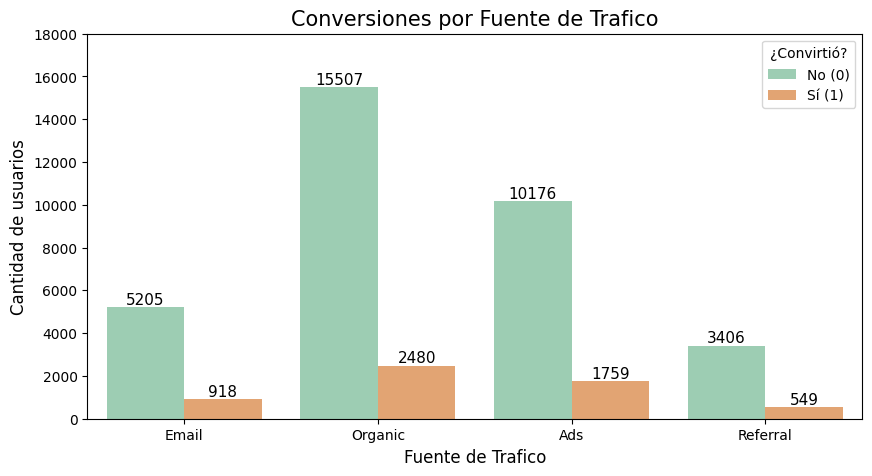

In [ ]:
# Gráfico de barras agrupadas perzonalizado
plt.figure(figsize=(10, 5))
ax = sns.countplot(data=df, x='traffic_source', hue='converted', palette = ["#95D5B2", "#F4A261"] )

# Agregar valores
for bar in ax.patches:        # Recorrer todas las barras del gráfico
    height = bar.get_height() # Obtener altura de barra (conteo de usuarios)
    ax.text(x=bar.get_x()+bar.get_width() /2, # Establecer coordenada X del texto (centro de la barra)
            y=height,                         # Establecer coordenada Y del texto
            s=height,                         # Valor a mostrar
            ha='center',                      # Alinear centro del texto en coordenada
            va='bottom',                      # Alinear parte inferior del texto en coordenada
            fontsize=11)                      # Tamaño de la fuente

# Añadir detalles
plt.title('Conversiones por Fuente de Trafico', fontsize=15)
plt.xlabel('Fuente de Trafico', fontsize=12)
plt.ylabel('Cantidad de usuarios', fontsize=12)
plt.ylim(0,18000)
plt.legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'])
plt.show()

✍️ **Comentario**:

**Conversiones por Fuente de Tráfico — Conteo Absoluto**

1. Descripción básica: Este gráfico muestra la cantidad de usuarios que convirtieron y no convirtieron, distribuidos según su fuente de tráfico (Email, Organic, Ads y Referral).

2. Patrón principal: Organic es el canal con mayor volumen absoluto de conversiones (2,480), seguido por Ads (1,759), Email (918) y Referral (549). Sin embargo, también es el canal con más usuarios que no convirtieron (15,507), lo que refleja su alto volumen general de tráfico. Email, en cambio, presenta un volumen total mucho menor pero una relación conversión/no-conversión visualmente más equilibrada.

3. Insight clave: El volumen absoluto de conversiones no debe interpretarse aisladamente: Organic lidera en cantidad, pero su gran base de usuarios no convertidos sugiere que la efectividad del canal podría ser menor de lo que parece — algo que el gráfico de Tasa de Conversión (siguiente visualización) permitirá confirmar.

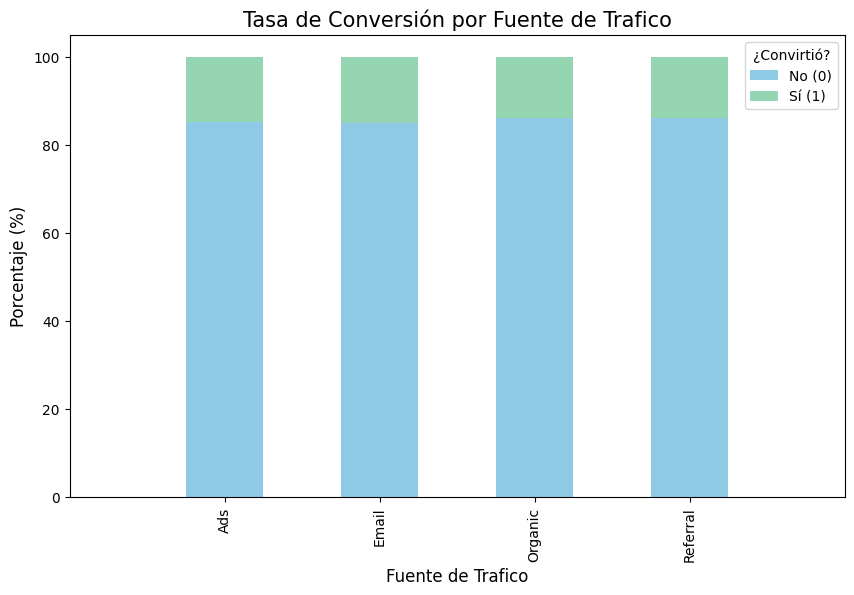

In [ ]:
# Gráfica de barras apiladas perzonalizado
ax = tabla_1_normalizada.plot(kind='bar', stacked=True, figsize=(10, 6), color=["#8ecae6", "#95d5b2"])

# Añadir detalles
plt.title('Tasa de Conversión por Fuente de Trafico', fontsize=15)
plt.ylabel('Porcentaje (%)', fontsize=12)
plt.xlabel('Fuente de Trafico', fontsize=12)
ax.set_xlim(-1, 4)
plt.legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'], loc='upper right')
plt.show()

✍️ **Comentario**:

**Tasa de Conversión por Fuente de Tráfico — Proporción**

1. Descripción básica: Este gráfico muestra la proporción de usuarios que convirtieron y no convirtieron dentro de cada fuente de tráfico (Ads, Email, Organic y Referral), permitiendo comparar la efectividad de cada canal independientemente de su volumen.

2. Patrón principal: Las cuatro fuentes de tráfico presentan tasas de conversión notablemente similares, todas situadas aproximadamente entre el 13% y el 15%. Ningún canal destaca de forma evidente sobre los demás, lo que contrasta con las diferencias en volumen absoluto observadas en el gráfico anterior.

3. Insight clave: Aunque las diferencias visuales son sutiles, el test Chi-cuadrado de independencia (p = 0.034 < 0.05) confirma que sí existe una asociación estadísticamente significativa entre la fuente de tráfico y la conversión. Esto indica que el canal por el que llega el usuario sí influye en su probabilidad de convertir.

### Relación entre el tipo de usuario y la conversión

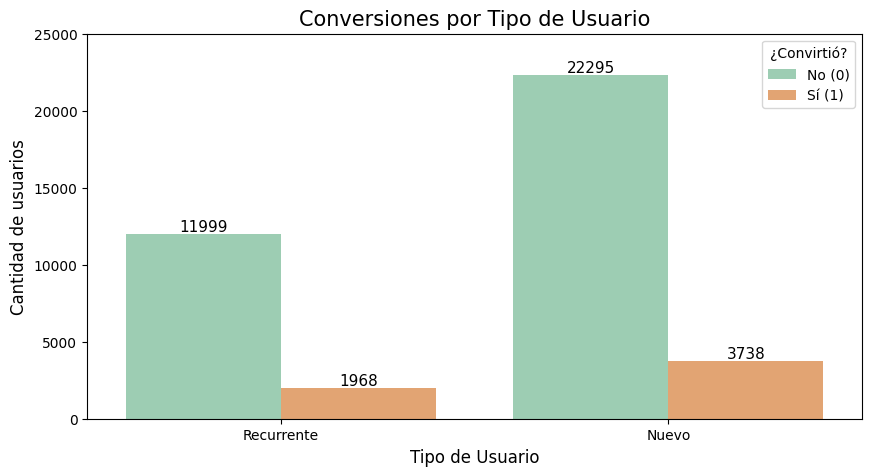

In [ ]:
# Gráfico de barras agrupadas
plt.figure(figsize=(10, 5))
ax = sns.countplot(data=df, x='user_type', hue='converted', palette = ["#95D5B2", "#F4A261"] )

# Agregar valores
for bar in ax.patches:        # Recorrer todas las barras del gráfico
    height = bar.get_height() # Obtener altura de barra (conteo de usuarios)
    ax.text(x=bar.get_x()+bar.get_width() /2, # Establecer coordenada X del texto (centro de la barra)
            y=height,                         # Establecer coordenada Y del texto
            s=height,                         # Valor a mostrar
            ha='center',                      # Alinear centro del texto en coordenada
            va='bottom',                      # Alinear parte inferior del texto en coordenada
            fontsize=11)                      # Tamaño de la fuente

# Añadir detalles
plt.title('Conversiones por Tipo de Usuario', fontsize=15)
plt.xlabel('Tipo de Usuario', fontsize=12)
plt.ylabel('Cantidad de usuarios', fontsize=12)
plt.ylim(0,25000)
plt.legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'])
plt.show()

✍️ **Comentario**:

**Conversiones por Tipo de Usuario — Conteo Absoluto**

1. Descripción básica: Este gráfico muestra la cantidad de usuarios que convirtieron y no convirtieron, distribuidos según su tipo de usuario (Recurrente y Nuevo).

2. Patrón principal: Los usuarios nuevos representan el mayor volumen: 22,295 no convirtieron y 3,738 sí lo hicieron. Los usuarios recurrentes, aunque en menor cantidad, muestran que 11,999 no convirtieron y 1,968 convirtieron. En términos absolutos, los usuarios nuevos generan casi el doble de conversiones que los recurrentes.

3. Insight clave: El mayor volumen de conversiones en usuarios nuevos responde principalmente a su mayor representación en el experimento, no necesariamente a una mayor efectividad. Al igual que con las fuentes de tráfico, el gráfico de proporciones será clave para determinar si el tipo de usuario influye realmente en la probabilidad de convertir.

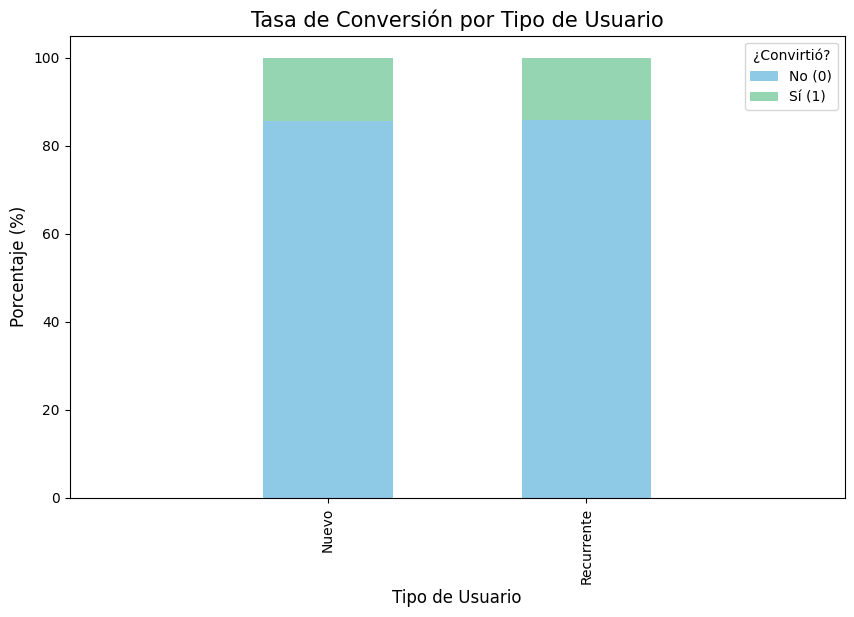

In [ ]:
# Gráfica de barras apiladas perzonalizado
ax = tabla_2_normalizada.plot(kind='bar', stacked=True, figsize=(10, 6), color=["#8ecae6", "#95d5b2"])

# Añadir detalles
plt.title('Tasa de Conversión por Tipo de Usuario', fontsize=15)
plt.ylabel('Porcentaje (%)', fontsize=12)
plt.xlabel('Tipo de Usuario', fontsize=12)
ax.set_xlim(-1, 2)
plt.legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'], loc='upper right')
plt.show()

✍️ **Comentario**:

**Tasa de Conversión por Tipo de Usuario — Proporción**

1. Descripción básica: Este gráfico muestra la proporción de usuarios que convirtieron y no convirtieron dentro de cada tipo de usuario (Nuevo y Recurrente), permitiendo comparar su efectividad relativa independientemente del volumen.
   
2. Patrón principal: Ambos tipos de usuario presentan tasas de conversión prácticamente idénticas, situadas alrededor del 14-15%. Las barras son visualmente indistinguibles, confirmando lo que el gráfico de conteo absoluto no podía revelar por sí solo: que la diferencia en conversiones entre nuevos y recurrentes se explica por el volumen, no por una mayor propensión a convertir.

3. Insight clave: El test Chi-cuadrado de independencia (p = 0.474 > 0.05) confirma que no existe asociación estadísticamente significativa entre el tipo de usuario y la conversión. Esto indica que ser usuario nuevo o recurrente no influye en la probabilidad de convertir, por lo que segmentar la estrategia de marketing exclusivamente por este criterio no estaría respaldado por los datos.

## 🧩 Paso 7. Insight Ejecutivo para Stakeholders

Se traducen los hallazgos del análisis del experimento A/B en conclusiones accionables para el negocio, enfocadas en **versión de página, conversión, gasto promedio, canales de tráfico y tipo de usuario**.

**Preguntas a responder:**  
- ¿Qué página genera mayor conversión y gasto promedio?  
- ¿Qué canales de tráfico son más efectivos para generar conversiones?  
- ¿Existen diferencias significativas según el tipo de usuario?  
- ¿Qué recomendaciones se pueden tomar para optimizar la estrategia de marketing?


---

### 🌟 Insight Ejecutivo basado en el Experimento A/B

#### 🔍 **Comparación de página (A vs B)**  

**Gasto promedio por usuario que convirtió:**
- **Observacion 1**: Los usuarios que convirtieron en la versión B gastaron en promedio 68, frente a 61 en la versión A, una diferencia de 7 por usuario convertido que representa un incremento aproximado del 10%. La prueba t de Student confirma que esta diferencia es estadísticamente significativa (p = 1.06e-20 < 0.05), descartando que sea producto del azar.
- **Observacion 2**: Los 3,194 usuarios que convirtieron en la versión B generaron un ingreso adicional estimado de 22,358 en comparación con la versión A, lo que evidencia que el impacto económico de la diferencia no es marginal sino acumulativamente relevante para el negocio.
- **Interpretación:** La versión B no solo atrae más conversiones, sino que también induce un mayor gasto por usuario que convierte. Esto sugiere que el diseño o contenido de la página B genera una experiencia que impulsa compras de mayor valor, lo cual tiene un impacto directo y medible en los ingresos del negocio.

<br>

**Tasa de conversión:**
- **Observacion 1**: La versión B alcanzó una tasa de conversión del 15.96%, superando en 3.38 puntos porcentuales a la versión A (12.57%). El Z-test de proporciones confirma que esta diferencia es estadísticamente significativa (p = 3.76e-22 < 0.05), descartando que sea producto del azar.
- **Observacion 2**: Proyectando sobre un tráfico de 20,000 usuarios mensuales, la versión B generaría aproximadamente 3,000 conversiones frente a 2,400 de la versión A, lo que se traduce en cerca de 600 ventas adicionales por mes únicamente por el cambio de versión.
- **Interpretación:** Aunque una diferencia del 3% puede parecer modesta en términos relativos, su impacto acumulado es significativo a escala. La versión B convierte más visitantes en compradores de forma consistente y comprobada estadísticamente, lo que la posiciona como la opción superior para maximizar el volumen de ventas del negocio.

---

#### 📊 **Segmentación por fuente de tráfico**
- **Observacion**: El Chi-cuadrado de independencia (p = 0.034 < 0.05) confirma que la conversión sí depende de la fuente de tráfico. En términos absolutos, Organic lidera en volumen de conversiones (2,480), seguido de Ads (1,759), Email (918) y Referral (549); sin embargo, al analizar las tasas de conversión el orden cambia: Email es el canal más eficiente (14.99%), seguido de Ads (14.73%), Referral (13.88%) y Organic (13.78%), evidenciando que un mayor volumen de tráfico no equivale necesariamente a una mayor efectividad por usuario.
- **Interpretación:** El negocio enfrenta una decisión estratégica entre volumen y eficiencia: Email convierte mejor por usuario pero trae menos tráfico, mientras que Organic aporta el mayor número absoluto de conversiones pero con la tasa más baja. Esto sugiere priorizar la inversión en Email para maximizar la eficiencia de conversión, mantener Organic como pilar de crecimiento a largo plazo, y revisar el ROI de Ads y Referral antes de escalar su inversión.

 ---

#### 📊 **Segmentación por tipo de usuario**
- **Observacion**: El Chi-cuadrado de independencia (p = 0.474 > 0.05) confirma que la conversión no depende del tipo de usuario. Aunque en términos absolutos los usuarios nuevos registran más conversiones (3,738) frente a los recurrentes (1,968), las tasas de conversión son prácticamente idénticas: Nuevo (14.35%) vs Recurrente (14.09%), una diferencia de apenas 0.26 puntos porcentuales que no es estadísticamente significativa, indicando que la brecha en valores absolutos se explica por el mayor volumen de usuarios nuevos en el experimento, no por una mayor propensión a convertir.
- **Interpretación:** Dado que ambos tipos de usuario convierten en proporciones equivalentes, no es necesario segmentar las estrategias de conversión por este criterio. Los recursos de marketing pueden unificarse en una sola estrategia para ambos grupos, evitando costos operativos innecesarios de segmentación. Esto libera capacidad para enfocar los esfuerzos de optimización en variables que sí mostraron impacto significativo, como la versión de página y la fuente de tráfico.

---

Las visualizaciones usadas respaldan los resultados estadísticos de pasos anteriores.

---

#### 💡 **Recomendaciones de negocio:**
- **Recomendación 1**: Implementar la versión B de la landing page como versión definitiva en producción, dado que genera una tasa de conversión 3.38 puntos porcentuales superior a la versión A (15.96% vs 12.57%) y un gasto promedio por usuario convertido un 10% mayor (68 vs 61), con el fin de maximizar simultáneamente el volumen de ventas y el ingreso por usuario.
- **Recomendación 2**: Priorizar la inversión en el canal Email como estrategia de adquisición principal, dado que es la fuente de tráfico con la mayor tasa de conversión (14.99%) y que el análisis estadístico confirmó que la fuente de tráfico sí influye en la probabilidad de conversión (p = 0.034), con el fin de maximizar la eficiencia del gasto en marketing, complementando con Organic como canal de volumen a largo plazo y revisando el ROI de Ads y Referral antes de escalar su inversión.

In [ ]:
#Generación de CSV:
df.to_csv('landing_experiment_2026.csv', index=False)